# TB and canonical Hubbard CAS

Use geom/608M4.xyz for the supplied example. The two manual hopping/onsite
cells are optional, structure-specific edits retained for specialized use;
skip them for the unmodified 44-site example.
Independent exploratory examples are in mfh_examples.ipynb.


In [1]:
import ase
import ase.io
import ase.visualize
import numpy as np
import pythtb
import os

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pltpe 

import tb_mean_field_hubbard as tbmfh
import tb_mean_field_hubbard.CAS as CAS
import tb_mean_field_hubbard.LMO as lmo

import pandas as pd


In [2]:
# Geometry
geom = ase.io.read("geom/trans-ind-dimer.xyz")

print(geom)
# Spin guess is set in atom tags (1 - up, 2 - down)
# one option to modify it is with the following (edit->modify & file->save):
ase.visualize.view(geom)

Atoms(symbols='C44', pbc=True, cell=[34.13930774518, 23.63506517714569, 15.0], tags=...)


In [3]:
# CALCULATION PARAMETERS

# hoppings in eV

t1 = 2.7 # first nearest neighbor 
t2 = 0 # second nearest neighbor
t3 = 0.1 # third nearest neighbor

# Only first nearest neighbor

# Up to third nearest neighbor
t_list = [t1, t2, t3]

charge = 0
multiplicity = 1


Total number of electrons: 44
α electrons: 22
β electrons: 22


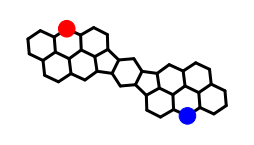

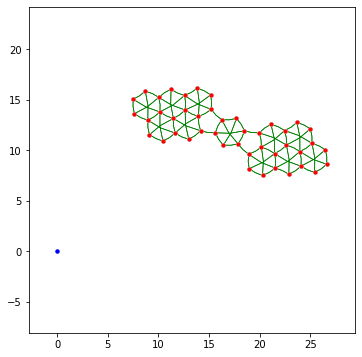

In [4]:
mfh_model = tbmfh.MeanFieldHubbardModel(geom, t_list, charge, multiplicity)

mfh_model.print_parameters()

mfh_model.visualize_spin_guess()
mfh_model.visualize_tb_model()


In [ ]:
# Optional structure-specific edit: 
k= 0.3
mfh_model.override_hoppings([
         (141,140,k),
    # (225,223, k),
    #    (16, 3, t),
])

#mfh_model.visualize_tb_model()
#mfh_model.model_a.display()

In [ ]:
# Optional structure-specific edit: 
mfh_model.set_onsite_energies([(141,0)],)

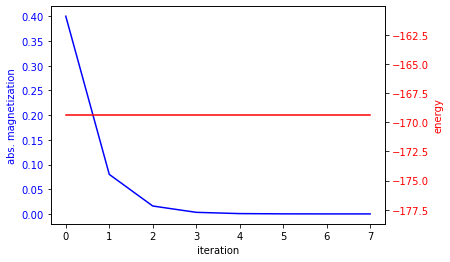

In [5]:
mfh_model.run_mfh(u =0, print_iter=False, plot=True)

multiplicity:                  1
abs. magnetization:       0.0000
energy:                -169.3876
---
spin density:


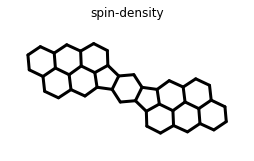

---
eigenvalues:


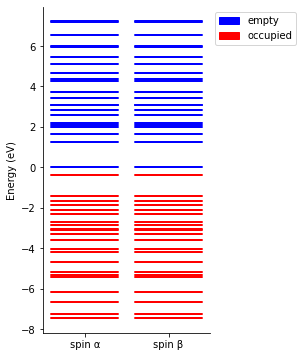

gap alpha: 0.4317
gap beta:  0.4317
gap eff.:  0.4317
---
frontier orbitals:


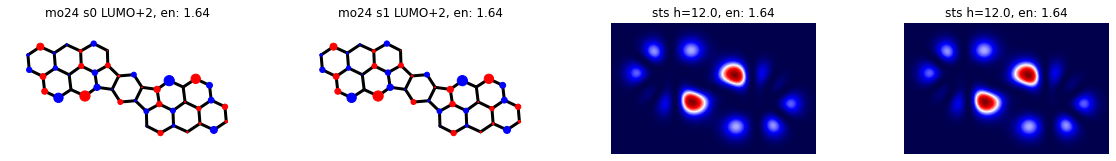

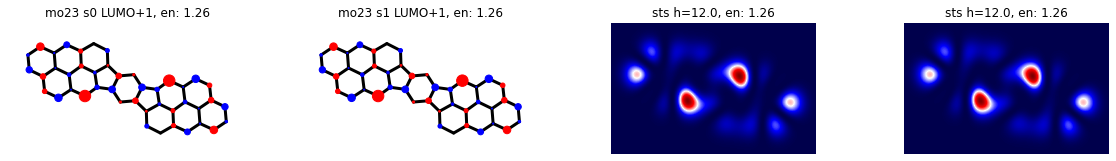

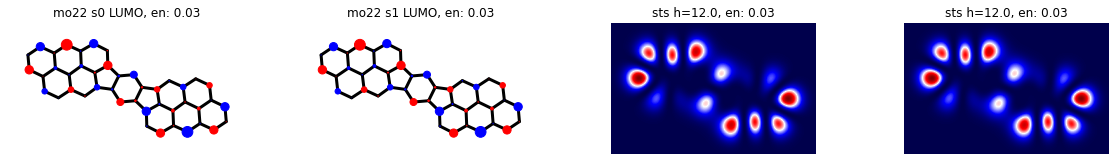

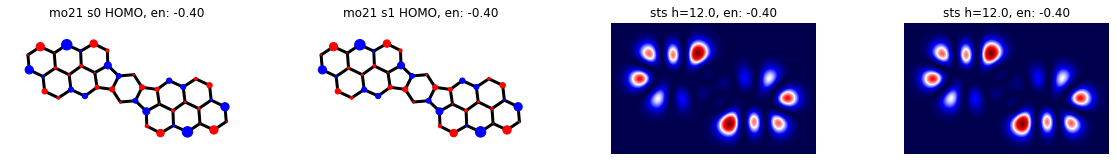

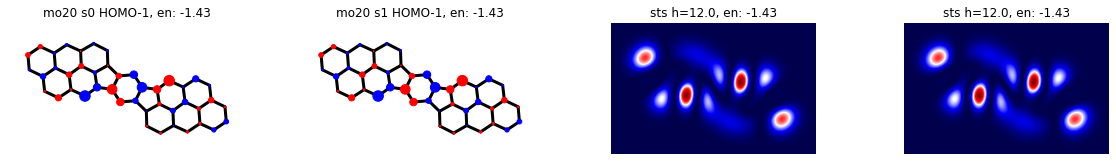

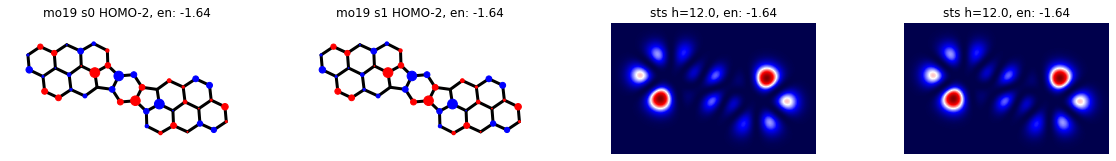

In [6]:
mfh_model.pp.report(num_orb=3, sts_h=12, sts_broad=0.01)

In [7]:
mfh_model.model_a.display()

---------------------------------------
report of tight-binding model
---------------------------------------
k-space dimension           = 0
r-space dimension           = 2
number of spin components   = 1
periodic directions         = []
number of orbitals          = 44
number of electronic states = 44
lattice vectors:
 #  0  ===>  [     1.0 ,     0.0 ]
 #  1  ===>  [     0.0 ,     1.0 ]
positions of orbitals:
 #  0  ===>  [ 23.6914 , 12.7357 ]
 #  1  ===>  [ 25.0234 , 12.1089 ]
 #  2  ===>  [ 19.9664 , 11.7137 ]
 #  3  ===>  [ 21.1325 , 12.5581 ]
 #  4  ===>  [ 22.4813 , 11.9425 ]
 #  5  ===>  [ 25.1843 , 10.6762 ]
 #  6  ===>  [  26.513 , 10.0383 ]
 #  7  ===>  [ 26.6393 ,  8.6066 ]
 #  8  ===>  [ 25.4409 ,  7.8028 ]
 #  9  ===>  [  22.661 , 10.5042 ]
 # 10  ===>  [ 23.9875 ,  9.8607 ]
 # 11  ===>  [ 24.1011 ,   8.419 ]
 # 12  ===>  [ 20.1807 , 10.2999 ]
 # 13  ===>  [  21.491 ,   9.662 ]
 # 14  ===>  [ 21.5522 ,   8.227 ]
 # 15  ===>  [ 20.2909 ,     7.5 ]
 # 16  ===>  [ 18.9717 , 

[ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
 -2.56e-06  2.56e-06]


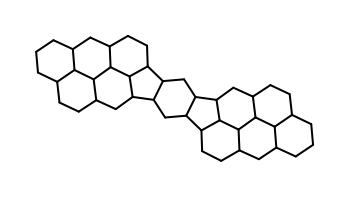

In [8]:
# ===== MFH spin-density visualization =====

# Plot the real-space spin-density distribution of the converged MFH state
mfh_model.print_spindensity(
    wid=2,          # Line-width parameter for the spin-density plot
    pointsize=2.5,  # Marker size for atomic sites
)

# Save the current spin-density figure as a PDF
plt.savefig(
    "spin_density_694_1spinL.pdf",
    bbox_inches="tight",
)

# Print the MFH spin-density values at individual sites
print(mfh_model.spin_density)


           0         1
0  -7.457021 -7.457021
1  -7.276500 -7.276500
2  -6.643844 -6.643844
3  -6.184466 -6.184466
4  -5.427977 -5.427977
5  -5.324558 -5.324558
6  -5.185376 -5.185376
7  -4.696374 -4.696374
8  -4.172133 -4.172133
9  -4.029898 -4.029898
10 -3.582472 -3.582472
11 -3.289553 -3.289553
12 -3.088456 -3.088456
13 -3.062457 -3.062457
14 -2.856139 -2.856139
15 -2.693246 -2.693246
16 -2.287348 -2.287348
17 -2.102985 -2.102985
18 -1.855465 -1.855465
19 -1.644149 -1.644149
20 -1.431445 -1.431445
21 -0.401921 -0.401921
22  0.029759  0.029759
23  1.255687  1.255687
24  1.638280  1.638280
25  1.984632  1.984632
26  2.078715  2.078715
27  2.200426  2.200426
28  2.604431  2.604431
29  2.812200  2.812200
30  3.062135  3.062135
31  3.070860  3.070860
32  3.451908  3.451908
33  3.708361  3.708361
34  4.271037  4.271037
35  4.381931  4.381931
36  4.647449  4.647449
37  5.136406  5.136406
38  5.447528  5.447528
39  5.947360  5.947360
40  6.012120  6.012120
41  6.525838  6.525838
42  7.20800

,0,1
19,-1.644149,-1.644149
20,-1.431445,-1.431445
21,-0.401921,-0.401921
22,0.029759,0.029759
23,1.255687,1.255687
24,1.638280,1.638280


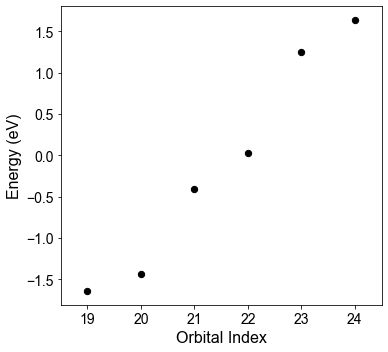

In [9]:
# ===== User parameters (edit this section only; all indices are zero-based) =====

start_orbital_param = 19  # First orbital index to display (inclusive)
end_orbital_param = 24    # Last orbital index to display (inclusive)
point_size_param = 40     # Scatter-point size
figure_size_param = (5.5, 5)  # Figure size
output_name_param = "dimer_U0.pdf"  # Output PDF filename

# ===== MFH eigenvalues =====

# Display all DataFrame columns
pd.set_option("display.max_columns", None)

# Convert the MFH eigenvalues into a table; rows correspond to orbital indices and columns to spin channels
data_evals = pd.DataFrame(mfh_model.evals).T

# Print the complete eigenvalue table and its dimensions
print(data_evals)
print("Shape of data:", data_evals.shape)

# Get the total number of orbitals
n_orbitals = data_evals.shape[0]

# Print the total number of orbitals
print(f"\nTotal orbitals: {n_orbitals}")

# ===== Validate and display the selected orbital range =====

# Check whether the selected orbital-index range is valid
if (
    start_orbital_param < 0
    or end_orbital_param >= n_orbitals
    or start_orbital_param > end_orbital_param
):
    print("Error: 轨道编号范围超出 data_evals 的有效范围 / Orbital-index range is outside the valid range of data_evals.")

else:
    # Print the currently selected orbital range
    print(
        f"\n显示第 {start_orbital_param} 到 {end_orbital_param} 个轨道 "
        f"(共 {end_orbital_param - start_orbital_param + 1} 个) / "
        f"Displaying orbitals {start_orbital_param} to {end_orbital_param} "
        f"({end_orbital_param - start_orbital_param + 1} orbitals):\n"
    )

    # Display the eigenvalues of the selected orbitals in Jupyter
    display(
        data_evals.iloc[
            start_orbital_param:end_orbital_param + 1
        ]
    )

# ===== Plot orbital energies in the selected range =====

# Extract eigenvalues of the first spin channel
y = data_evals.iloc[:, 0]

# Use zero-based orbital indices as the x-axis
x = y.index.to_numpy()

# Select the specified orbital range
mask = (
    (x >= start_orbital_param)
    & (x <= end_orbital_param)
)

x_filtered = x[mask]
y_filtered = y.iloc[mask]

# ===== Plot the orbital-energy scatter plot =====

# Create the figure
plt.figure(figsize=figure_size_param)

# Plot the eigenvalues of the selected orbitals
plt.scatter(
    x_filtered,
    y_filtered,
    color="black",
    s=point_size_param,
)

# Set axis labels
plt.xlabel(
    "Orbital Index",
    fontsize=16,
    fontname="Arial",
)

plt.ylabel(
    "Energy (eV)",
    fontsize=16,
    fontname="Arial",
)

# Set tick-label fonts
plt.xticks(
    fontsize=14,
    fontname="Arial",
)

plt.yticks(
    fontsize=14,
    fontname="Arial",
)

# Set the x-axis range with small margins on both sides
plt.xlim(
    start_orbital_param - 0.5,
    end_orbital_param + 0.5,
)

# Optimize the figure layout
plt.tight_layout()

# Save the figure as a PDF
plt.savefig(
    output_name_param,
    format="pdf",
    bbox_inches="tight",
)

# Display the figure
plt.show()

# Print the complete eigenvalue data

# Print the raw eigenvalues stored in the MFH model


Orbital index: 25, spin: 0
Energy: 1.984632 eV
Eigenvector shape: (44,)
Eigenvector ndim: 1


<Figure size 432x288 with 0 Axes>

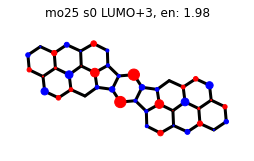

<Figure size 432x288 with 0 Axes>

U_orbital: 0.189323 eV


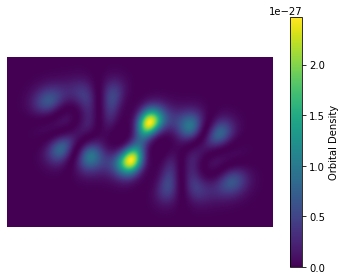

In [11]:
# ===== User parameters (edit this section only; all indices are zero-based) =====

orbital_index_param = 25          # Orbital index to analyze (zero-based)
spin_param = 0                    # Spin channel: 0 or 1
output_prefix_param = "561_NO3"   # Output filename prefix

# ===== Extract the selected MFH orbital =====

# Print the orbital index and spin channel being analyzed
print(
    f"Orbital index: {orbital_index_param}, "
    f"spin: {spin_param}"
)

# Extract the eigenenergy of the selected orbital
orbital_energy = mfh_model.evals[spin_param][orbital_index_param]

# Print the orbital energy
print(
    f"Energy: {orbital_energy:.6f} eV"
)

# Extract the eigenvector corresponding to the selected spin channel and orbital index
evec = mfh_model.evecs[spin_param][orbital_index_param]

# Print the eigenvector shape and dimensionality for inspection
print("Eigenvector shape:", evec.shape)
print("Eigenvector ndim:", evec.ndim)

# ===== Visualize the orbital eigenvector =====

# Create a new figure to avoid overlap with previous plots
plt.figure()

# Plot the eigenvector of the selected MFH molecular orbital
mfh_model.pp.plot_mo_eigenvector(
    mo_index=orbital_index_param,
    spin=spin_param,
)

# Optimize the figure layout
plt.tight_layout()

# Save the orbital-eigenvector figure
plt.savefig(
    f"{output_prefix_param}.pdf",
    format="pdf",
    bbox_inches="tight",
)

# Display the figure
plt.show()

# ===== Calculate the orbital-local Hubbard interaction =====

# Calculate U_eff = U * sum_i |psi_i|^4 as the local Hubbard-interaction scale of the orbital in the site basis
orbital_U_site_param = 3.5  # Interaction used only for this single-orbital diagnostic.
U_orbital = orbital_U_site_param * np.sum(np.abs(evec) ** 4)

# Print the effective orbital Hubbard interaction
print(f"U_orbital: {U_orbital:.6f} eV")

# ===== Visualize the orbital probability density =====

# Create a separate figure
fig, ax = plt.subplots(
    figsize=(5, 4)
)

# Plot the spatial distribution of the orbital probability density |psi|^2
mfh_model.pp.plot_orb_squared_map(
    ax,
    evec,
    cmap="viridis",
)

# Retrieve the mappable object generated by the plotting function for the colorbar
mappables = ax.collections if ax.collections else ax.images

# Automatically add a colorbar if a suitable mappable object exists
if mappables:
    plt.colorbar(
        mappables[-1],
        ax=ax,
        label="Orbital Density",
    )

# Optimize the figure layout
plt.tight_layout()

# Save the orbital-density map
plt.savefig(
    f"{output_prefix_param}_map.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

# Close the current figure to prevent reuse in subsequent plots
plt.close(fig)

# CAS: inspect results before choosing the next stage

Run the TB cells first. Each code cell below contains only its own parameters and one analysis call. Stop to inspect its tables/plots before configuring the next stage. Earlier results are reused; the full CAS solver is called only in the first stage. All indices are zero-based.

After changing a root or NO selection, rerun the dependent cells in order. Pair-analysis cells check their observable object against the current LMO/MIX basis and reject stale results. Root defaults follow the inspected/localized state; change them explicitly to compare another state in a fixed basis.

## Canonical-MO CAS

Choose the active orbitals, electron count and number of roots from the TB results. MFH U=0 defines the one-electron reference; U_site_param is the separate CAS interaction.

In [12]:
from tb_mean_field_hubbard.cas_stages import solve_canonical_cas
from tb_mean_field_hubbard.cas_workflow import PairAnalysis

active_indices = [19, 20, 21, 22, 23, 24]
n_elec_param = 6
n_roots_param = 6
U_site_param = 3.5
spin_param = 0
result_folder = "results/trans_ind_dimer_t3"

# Solve CAS only; do not select roots, NOs or LMO pairs yet.
cas_session = solve_canonical_cas(
    mfh_model, active_indices=active_indices, U_site_param=U_site_param,
    n_elec_param=n_elec_param, n_roots_param=n_roots_param,
    spin_param=spin_param, result_folder=result_folder,
)

=== Hubbard-CAS energies ===
root  0 (   ground): E = -6.073129519894,  dE = 0.000000000000
root  1 (excited 1): E = -5.807643818520,  dE = 0.265485701374
root  2 (excited 2): E = -5.807643818520,  dE = 0.265485701374
root  3 (excited 3): E = -5.807643818520,  dE = 0.265485701374
root  4 (excited 4): E = -5.446108452387,  dE = 0.627021067507
root  5 (excited 5): E = -5.171061769633,  dE = 0.902067750261

=== CI expansion: root 0 ===
alpha_occ beta_occ               coeff    weight
   111000   111000 -0.976366+0.000000j  0.953291
   110100   110100  0.200698+0.000000j  0.040280
   101010   101010  0.026242+0.000000j  0.000689
   110010   110010  0.023736+0.000000j  0.000563
   101001   101001  0.019256+0.000000j  0.000371
   111000   101100  0.017085+0.000000j  0.000292
   101100   111000  0.017085+0.000000j  0.000292
   110010   011100 -0.016487+0.000000j  0.000272
   011100   110010 -0.016487+0.000000j  0.000272
   110001   110001  0.014420+0.000000j  0.000208
   110100   011010 -0.01

## Root report

After inspecting the CAS energies, choose which roots to compare. Raw CAS data remain available as cas_session.cas_data.

In [25]:
report_roots = (0,)

# Inspect occupations without rerunning CAS.
root_report = cas_session.report_roots(report_roots=report_roots)

      energy_eV  excitation_eV
root                          
0     -6.073130       0.000000
1     -5.807644       0.265486
2     -5.807644       0.265486
3     -5.807644       0.265486
4     -5.446108       0.627021
5     -5.171062       0.902068
Root 0 natural occupations: [1.99917268 1.99444617 1.91502201 0.08345986 0.0052368  0.00266249]


## Root natural-orbital analysis

Choose a root using the CAS spectrum and root report. Inspect the NO plots and occupations before selecting a localization subspace.

 NO    NO_occ  active_MO               coeff  abs_coeff
  0  1.999173         19 -0.782089-0.000000j   0.782089
  0  1.999173         20  0.623109+0.000000j   0.623109
  0  1.999173         22  0.007431+0.000000j   0.007431
  0  1.999173         24  0.004178+0.000000j   0.004178
  1  1.994446         19  0.623147+0.000000j   0.623147
  1  1.994446         20  0.781881+0.000000j   0.781881
  1  1.994446         22  0.016268+0.000000j   0.016268
  1  1.994446         24  0.009244+0.000000j   0.009244
  2  1.915022         21 -0.999923+0.000000j   0.999923
  2  1.915022         23 -0.012396+0.000000j   0.012396
  3  0.083460         19 -0.004144+0.000000j   0.004144
  3  0.083460         20 -0.016634+0.000000j   0.016634
  3  0.083460         22  0.997461+0.000000j   0.997461
  3  0.083460         24 -0.069115+0.000000j   0.069115
  4  0.005237         21  0.012396+0.000000j   0.012396
  4  0.005237         23 -0.999923+0.000000j   0.999923
  5  0.002662         19 -0.002786+0.000000j   0

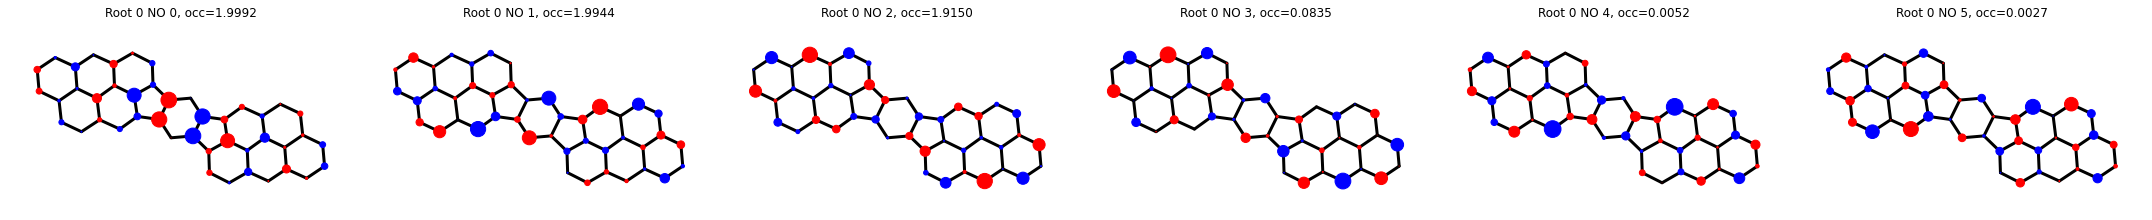

Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_0_occ_1.9992.pdf
Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_1_occ_1.9944.pdf
Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_2_occ_1.9150.pdf
Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_3_occ_0.0835.pdf
Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_4_occ_0.0052.pdf
Saved: trans_ind_dimer_t3\CAS(6,6)\CAS\CAS_root0_root0_NO_5_occ_0.0027.pdf


In [26]:
root_param = 0
cutoff_param = 1e-3
show_param = True

no_analysis = cas_session.natural_orbitals(
    root_param=root_param, cutoff_param=cutoff_param, save_plots=True, show=show_param,
)

## CAS-LMO localization

Choose the NO subset after inspecting the preceding CAS/NO results. Inspect the resulting LMO plots before selecting target or mixing pairs.

[PM LineSearch Iter    1] f = 0.698577319796, df = +3.621e-01, max angle = 45.000000 deg
[PM LineSearch Iter    2] f = 0.867612955518, df = +1.690e-01, max angle = 40.000000 deg
[PM LineSearch Iter    3] f = 0.875640290104, df = +8.027e-03, max angle = 9.000000 deg
[PM LineSearch Iter    4] f = 0.875785960727, df = +1.457e-04, max angle = 1.000000 deg
[PM LineSearch Iter    5] f = 0.875786681253, df = +7.205e-07, max angle = 0.500000 deg
[PM LineSearch Iter    6] f = 0.875786681253, df = +0.000e+00, max angle = 0.000000 deg
Converged: max angle 0.000000 deg < 1e-06 deg
Selected NO occupations: [1.99917268 1.99444617 1.91502201 0.08345986 0.0052368  0.00266249]
NO expansion: rows = selected NOs, columns = LMOs
          0         1         2         3         4         5
0  0.958764 -0.115102  0.008296  0.118219 -0.164106 -0.162934
1 -0.084270  0.303944 -0.587199 -0.307658 -0.484675 -0.475553
2 -0.002069  0.611264  0.001026  0.610547 -0.355274  0.356880
3 -0.128513 -0.564979 -0.587883  

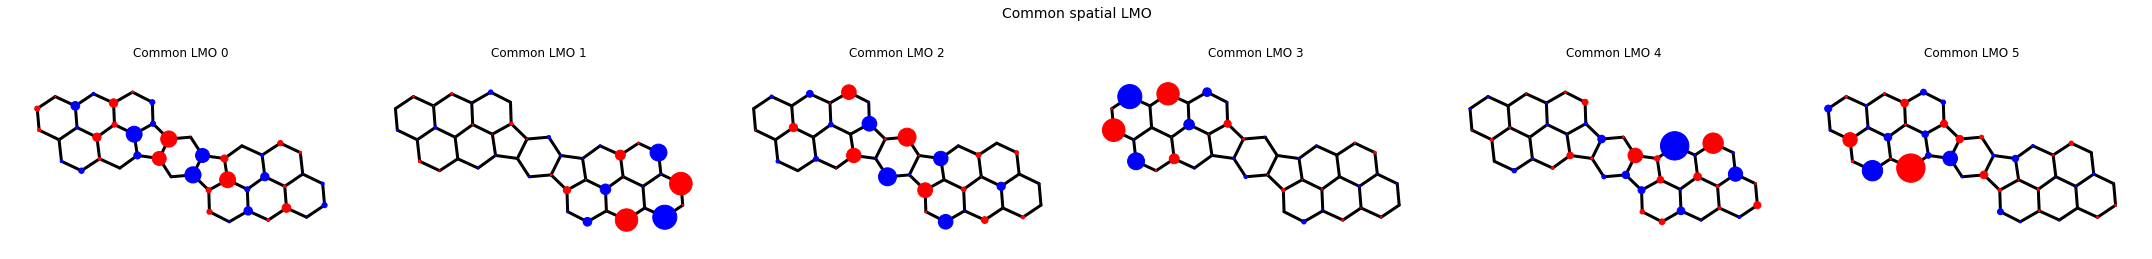

Common LMO 0 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_0.pdf
Common LMO 1 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_1.pdf
Common LMO 2 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_2.pdf
Common LMO 3 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_3.pdf
Common LMO 4 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_4.pdf
Common LMO 5 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO\CAS-LMO_root0_Common_LMO_5.pdf


In [27]:
root_param = no_analysis["root"]  # Follow the inspected NO root; override explicitly if needed.
selected_no_indices = (0, 1, 2, 3, 4, 5)
site_groups_param = None
max_iter_param = 1000
tol_param = 1e-6
max_angle_deg_param = 45.0
n_grid_param = 181
show_param = True

lmo_basis = cas_session.localize(
    root_param=root_param, selected_no_indices=selected_no_indices,
    site_groups=site_groups_param, max_iter=max_iter_param, tol=tol_param,
    max_angle_deg=max_angle_deg_param, n_grid=n_grid_param,
    save_plots=True, show=show_param,
)

## CAS-LMO observables

Transform the selected root into the inspected LMO basis. This constructs observables; it does not eliminate bridge orbitals.

In [28]:
root_param = lmo_basis.localization_root  # Default to the root used for localization.

lmo_observables = cas_session.observables(lmo_basis, root_param=root_param)

=== n_up ===
[0.9267   0.476889 0.358749 0.479006 0.383329 0.375327]

=== n_dn ===
[0.9267   0.476889 0.358749 0.479006 0.383329 0.375327]

=== n_tot ===
[1.8534   0.953778 0.717499 0.958012 0.766658 0.750654]

=== m = n_up - n_dn ===
[0. 0. 0. 0. 0. 0.]

=== B = Re(rho_up + rho_dn) ===
[[ 1.8534   -0.267895  0.12054   0.269656 -0.231472 -0.233608]
 [-0.267895  0.953778 -0.329362  0.474851 -0.670883  0.165577]
 [ 0.12054  -0.329362  0.717499  0.336175  0.562985  0.553599]
 [ 0.269656  0.474851  0.336175  0.958012 -0.155552  0.669666]
 [-0.231472 -0.670883  0.562985 -0.155552  0.766658  0.269048]
 [-0.233608  0.165577  0.553599  0.669666  0.269048  0.750654]]

=== H_eff_avg ===
[[-1.359258+0.j  0.369795+0.j -0.364454+0.j -0.375543+0.j  0.336864+0.j
   0.339882+0.j]
 [ 0.369795+0.j  0.015484+0.j  0.019408+0.j  0.023944+0.j  0.813681+0.j
   0.077223+0.j]
 [-0.364454+0.j  0.019408+0.j -0.04331 +0.j -0.028244+0.j -0.829075+0.j
  -0.81376 +0.j]
 [-0.375543+0.j  0.023944+0.j -0.028244+0.j  0.

## CAS-LMO spin correlations

Choose roots to compare in this fixed LMO basis. Cached CI operator expectations are reused.

In [ ]:
correlation_roots = (0, 1, 2, 3)
connected_param = True

lmo_correlations = cas_session.spin_correlations(
    lmo_basis, correlation_roots=correlation_roots, connected=connected_param,
)

## CAS-LMO hopping downfolding

Choose targets and bridge indices from the LMO results. The observable object carries its exact basis into this calculation.

In [29]:
# Define the target LMO pair (1, 3) and the mediating subspace formed by LMOs (0, 2, 4, 5).
lmo_pair = PairAnalysis(1, 3, (0, 2, 4, 5), E_ref=None)   

lmo_downfolding = cas_session.downfold(lmo_observables, pair=lmo_pair, expected_basis=lmo_basis)

=== Downfolded hopping between two LMOs ===
H_key: H_eff_avg
LMO pair: 1 - 3
Bridge indices: [0, 2, 4, 5]
E_ref: 0.012454215662357847

--- hopping ---
t_direct = (0.023943826299882585+0j)
t_bridge = (-0.3587910423354321+0j)
t_total  = (-0.3348472160355495+0j)

--- |hopping| ---
|t_direct| = 0.023943826299882585
|t_bridge| = 0.3587910423354321
|t_total|  = 0.3348472160355495

--- magnetic texture proxy: |t|^2 * |m_a m_b| ---
m_a = 0.0
m_b = 0.0
|m_a m_b| = 0.0
J_t2m_direct = 0.0
J_t2m_bridge = 0.0
J_t2m_total  = 0.0

--- signed texture proxy: |t|^2 * (m_a m_b) ---
signed_J_t2m_direct = 0.0
signed_J_t2m_bridge = 0.0
signed_J_t2m_total  = 0.0

--- covalency proxy: |t| * |B_ab| ---
B_ab = 0.4748507740138428
|B_ab| = 0.4748507740138428
J_tB_direct = 0.011369744451352252
J_tB_bridge = 0.17037220416221335
J_tB_total  = 0.1590024597108611

--- effective U ---
U_a   = 0.6302949105742555
U_b   = 0.6300256156724555
U_eff = 0.6301602631233555

--- AFM superexchange estimate: 4|t|^2/U_eff ---
J_AFM

## CAS-LMO bridge eigenchannels

Reuse the same pair and reference energy to compare channel contributions with the preceding downfolding.

In [30]:
# Edit lmo_pair in the preceding cell to change the targets or reference energy.
lmo_channels = cas_session.channels(lmo_observables, pair=lmo_pair, expected_basis=lmo_basis)

   channel  epsilon_mu  denominator              V_a_mu              V_mu_b  \
0        2    0.817350    -0.804896 -0.518276+0.000000j -0.515598+0.000000j   
1        1   -1.164598     1.177052 -0.501448+0.000000j  0.505768+0.000000j   
2        3    1.278780    -1.266326  0.509107+0.000000j -0.512627+0.000000j   
3        0   -1.510230     1.522684 -0.160979+0.000000j  0.164792+0.000000j   

                 t_mu  abs_t_mu  phase_t_mu  weight_LMO_0  weight_LMO_2  \
0 -0.331996-0.000000j  0.331996   -3.141593  1.816085e-07      0.000061   
1 -0.215468+0.000000j  0.215468    3.141593  4.315464e-02      0.541067   
2  0.206094-0.000000j  0.206094   -0.000000  4.878280e-02      0.458861   
3 -0.017422+0.000000j  0.017422    3.141593  9.080624e-01      0.000011   

   weight_LMO_4  weight_LMO_5  
0      0.496555      0.503384  
1      0.213062      0.202717  
2      0.244221      0.248135  
3      0.046162      0.045765  
Channel sum: (-0.3587910423354319+0j)
Exact bridge contribution: (-0

## Plus/minus CAS-LMO mixing

Select the mixing pair after inspecting the LMO results. Because the localized-orbital representation is not unique, the resulting LMOs do not always provide the most physically intuitive basis. For selected LMO pairs, symmetric and antisymmetric linear combinations can recover a basis with a clearer physical interpretation. Inspect the resulting MIX orbitals before choosing the MIX targets and mediating subspace.

Mixed orbitals: rows = NOs, columns = MIX orbitals
[[ 0.683815+0.j -0.115102+0.j  0.672083+0.j  0.118219+0.j -0.164106+0.j
  -0.162934+0.j]
 [-0.474801+0.j  0.303944+0.j  0.355624+0.j -0.307658+0.j -0.484675+0.j
  -0.475553+0.j]
 [-0.000738+0.j  0.611264+0.j -0.002188+0.j  0.610547+0.j -0.355274+0.j
   0.35688 +0.j]
 [-0.506569+0.j -0.564979+0.j  0.324823+0.j  0.564289+0.j  0.009555+0.j
   0.012771+0.j]
 [-0.004964+0.j  0.357344+0.j  0.003659+0.j  0.354802+0.j  0.608327+0.j
  -0.61345 +0.j]
 [-0.224333+0.j  0.271716+0.j  0.562412+0.j -0.272574+0.j  0.491718+0.j
   0.493412+0.j]]
Expansion weights:
[[0.467602 0.013248 0.451695 0.013976 0.026931 0.026547]
 [0.225436 0.092382 0.126469 0.094653 0.23491  0.226151]
 [0.000001 0.373644 0.000005 0.372768 0.12622  0.127363]
 [0.256612 0.319201 0.10551  0.318422 0.000091 0.000163]
 [0.000025 0.127695 0.000013 0.125884 0.370062 0.376321]
 [0.050325 0.07383  0.316307 0.074296 0.241786 0.243455]]
Common LMO 0 U_orbital: 0.18720522592624353
Common L

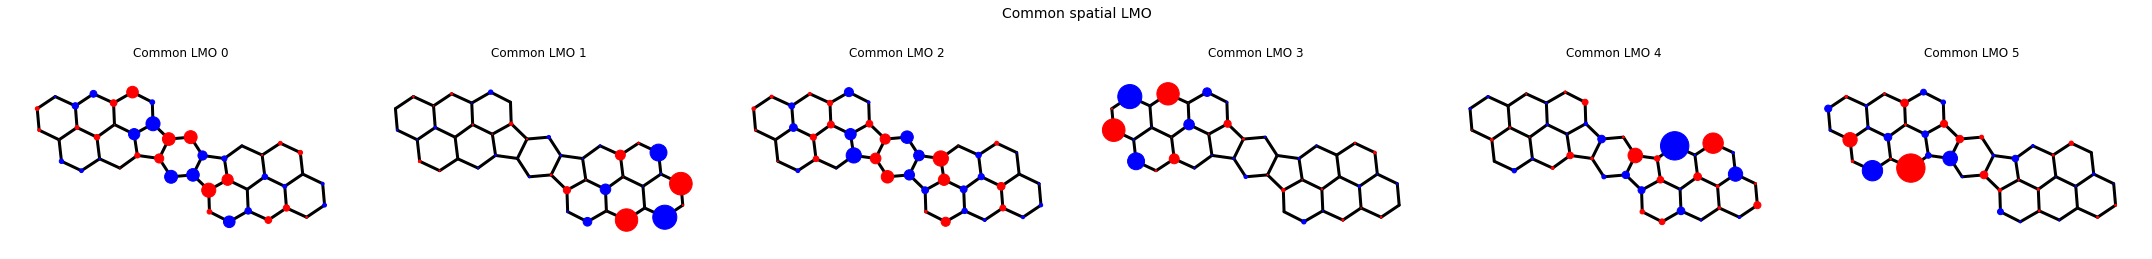

Common LMO 0 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_0.pdf
Common LMO 1 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_1.pdf
Common LMO 2 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_2.pdf
Common LMO 3 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_3.pdf
Common LMO 4 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_4.pdf
Common LMO 5 图已保存: trans_ind_dimer_t3\CAS(6,6)\CAS-LMO-MIX\CAS-LMO-MIX_root0_Common_LMO_5.pdf


In [31]:
mix_pair = (0, 2)
show_param = True

mix_basis = cas_session.mix(lmo_basis, mix_pair=mix_pair, save_plots=True, show=show_param)

## CAS-LMO-MIX observables

Build CAS observables in the newly inspected MIX basis, separately from the unmixed LMO observables.

In [ ]:
root_param = mix_basis.localization_root  # Default to the source localization root.

mix_observables = cas_session.observables(mix_basis, root_param=root_param)

## CAS-LMO-MIX hopping downfolding

Choose this pair only after inspecting the MIX orbitals and observables. Indices refer to the MIX basis.

In [ ]:
mix_analysis_pair = PairAnalysis(2, 3, (0, 1, 4, 5), E_ref=None)

mix_downfolding = cas_session.downfold(mix_observables, pair=mix_analysis_pair, expected_basis=mix_basis)

## CAS-LMO-MIX bridge eigenchannels

Use the same MIX pair and reference energy as the preceding downfolding.

In [ ]:
mix_channels = cas_session.channels(mix_observables, pair=mix_analysis_pair, expected_basis=mix_basis)

## Optional MIX spin correlations

Choose roots to inspect in the MIX basis; this does not rerun CAS or localization.

In [ ]:
correlation_roots = (0,)
connected_param = True

mix_correlations = cas_session.spin_correlations(
    mix_basis, correlation_roots=correlation_roots, connected=connected_param,
)